# 🚖 NYC Yellow Taxi Trip Duration Prediction
## NAIVE IMPLEMENTATION - No Best Practices
## Showing limitations without tracking, reproducibility, or SWE practices

In [1]:
# 📦 Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time
from datetime import datetime

# 🤷‍♂️ Random imports - no organization
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

print("Imports done!")

Imports done!


In [2]:
# 📥 Download data - hardcoded path
import kagglehub
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")
print(f"Data path: {path}")

Using Colab cache for faster access to the 'nyc-yellow-taxi-trip-data' dataset.
Data path: /kaggle/input/nyc-yellow-taxi-trip-data


In [3]:
# 📂 Load data - messy, no error handling
file = f"{path}/yellow_tripdata_2016-01.csv"
chunks = pd.read_csv(file, chunksize=500000, low_memory=False)
df1 = next(chunks)
df2 = next(chunks)
df = pd.concat([df1, df2], ignore_index=True)
print(f"Shape: {df.shape}")

Shape: (1000000, 19)


In [4]:
# 👀 Quick look - no systematic EDA
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RatecodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,2,2016-01-01 00:00:00,2016-01-01 00:00:00,2,1.10,-73.990372,40.734695,1,N,-73.981842,40.732407,2,7.5,0.5,0.5,0.0,0.0,0.3,8.8
1,2,2016-01-01 00:00:00,2016-01-01 00:00:00,5,4.90,-73.980782,40.729912,1,N,-73.944473,40.716679,1,18.0,0.5,0.5,0.0,0.0,0.3,19.3
2,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,10.54,-73.984550,40.679565,1,N,-73.950272,40.788925,1,33.0,0.5,0.5,0.0,0.0,0.3,34.3
3,2,2016-01-01 00:00:00,2016-01-01 00:00:00,1,4.75,-73.993469,40.718990,1,N,-73.962242,40.657333,2,16.5,0.0,0.5,0.0,0.0,0.3,17.3
4,2,2016-01-01 00:00:00,2016-01-01 00:00:00,3,1.76,-73.960625,40.781330,1,N,-73.977264,40.758514,2,8.0,0.0,0.5,0.0,0.0,0.3,8.8


In [5]:
# ⚠️ PROBLEM 1: No reproducibility - random seed NOT set!
# Every run gives different results

# ⚠️ PROBLEM 2: Hardcoded magic numbers everywhere
# ⚠️ PROBLEM 3: No documentation

# 🧹 Quick cleaning - doing everything in one cell

# Convert datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

# Create target
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# 🚨 HARDCODED FILTERS - no constants, just random numbers
df = df[df['trip_duration'] > 1]  # Why 1? Who knows!
df = df[df['trip_duration'] < 120]  # Why 120? Just feels right
df = df[df['trip_distance'] > 0.1]
df = df[df['trip_distance'] < 50]
df = df[df['passenger_count'] > 0]
df = df[df['passenger_count'] <= 6]

# Drop missing values silently
df = df.dropna()

# ⚠️ PROBLEM 4: Using data we wouldn't have at prediction time (DATA LEAKAGE!)
# Using fare_amount, tip_amount etc. which are only known AFTER the trip

# Select features - INCLUDING LEAKAGE FEATURES
feature_cols = [
    'tpep_pickup_datetime',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'passenger_count',
    'trip_distance',
    'fare_amount',      # ❌ DATA LEAKAGE - not known at pickup!
    'tip_amount',       # ❌ DATA LEAKAGE - not known at pickup!
    'total_amount',     # ❌ DATA LEAKAGE - not known at pickup!
    'VendorID',
    'RatecodeID',
    'payment_type'
]

X = df[feature_cols]
y = df['trip_duration']

print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"\n⚠️ USING LEAKAGE FEATURES: fare_amount, tip_amount, total_amount")

X shape: (985791, 13), y shape: (985791,)

⚠️ USING LEAKAGE FEATURES: fare_amount, tip_amount, total_amount


In [6]:
# ⚠️ PROBLEM 5: Feature engineering with leakage AND done BEFORE train/test split
# This causes data leakage from validation/test into training!

def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Feature engineering on ENTIRE dataset (BEFORE split) - CAUSES LEAKAGE!
X['haversine_distance'] = haversine(
    X['pickup_latitude'], X['pickup_longitude'],
    X['dropoff_latitude'], X['dropoff_longitude']
)

X['hour'] = pd.to_datetime(X['tpep_pickup_datetime']).dt.hour
X['dayofweek'] = pd.to_datetime(X['tpep_pickup_datetime']).dt.dayofweek
X['month'] = pd.to_datetime(X['tpep_pickup_datetime']).dt.month

# Create interaction features
X['distance_per_passenger'] = X['trip_distance'] / X['passenger_count']
X['fare_per_mile'] = X['fare_amount'] / X['trip_distance']  # ❌ Uses leakage!

# Drop datetime column
X = X.drop('tpep_pickup_datetime', axis=1)

# Convert to numeric
X = X.select_dtypes(include=[np.number])

print(f"Features after engineering: {X.shape[1]}")
print(f"\n❌ DATA LEAKAGE ISSUES:")
print("1. Feature engineering done BEFORE train/test split")
print("2. Using fare_amount, tip_amount, total_amount (post-trip info)")
print("3. Validation/test data influences scaling/transformations")

/tmp/ipython-input-3537194063.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['haversine_distance'] = haversine(
/tmp/ipython-input-3537194063.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['hour'] = pd.to_datetime(X['tpep_pickup_datetime']).dt.hour
/tmp/ipython-input-3537194063.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

Features after engineering: 18

❌ DATA LEAKAGE ISSUES:
1. Feature engineering done BEFORE train/test split
2. Using fare_amount, tip_amount, total_amount (post-trip info)
3. Validation/test data influences scaling/transformations


In [7]:
# ⚠️ PROBLEM 6: Train/test split with NO random_state - results not reproducible!
# Every run will have different splits

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# No random_state! Different split every time

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("❌ NO REPRODUCIBILITY: Different split each run!")

Train: (788632, 18), Test: (197159, 18)
❌ NO REPRODUCIBILITY: Different split each run!


In [8]:
# ⚠️ PROBLEM 7: Scaling with StandardScaler on entire training data
# This is actually correct, but no validation set!

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data scaled")

Data scaled


In [9]:
# ⚠️ PROBLEM 8: No validation set, no cross-validation
# Just train and test - can't detect overfitting properly

# Train multiple models with default parameters
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100)
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    
    y_pred = model.predict(X_test_scaled)
    
    results[name] = {
        'r2': r2_score(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
        'mae': mean_absolute_error(y_test, y_pred),
        'time': train_time
    }
    
    print(f"{name:20} | R²: {results[name]['r2']:.4f} | MAE: {results[name]['mae']:.2f} min | Time: {train_time:.2f}s")

Linear Regression    | R²: 0.7491 | MAE: 2.64 min | Time: 0.55s
Random Forest        | R²: 0.9640 | MAE: 0.77 min | Time: 1824.80s
Gradient Boosting    | R²: 0.9413 | MAE: 0.99 min | Time: 393.75s


In [10]:
# ⚠️ PROBLEM 9: No hyperparameter tuning, just default parameters
# Missing opportunity for better performance

# Just pick the best one based on test set (more leakage!)
best_model_name = max(results, key=lambda x: results[x]['r2'])
best_model = models[best_model_name]

print(f"🏆 Best model: {best_model_name}")
print(f"📊 Test R²: {results[best_model_name]['r2']:.4f}")
print(f"📊 Test MAE: {results[best_model_name]['mae']:.2f} minutes")
print("\n❌ PROBLEM: Tuning on test set - overly optimistic performance!")

🏆 Best model: Random Forest
📊 Test R²: 0.9640
📊 Test MAE: 0.77 minutes

❌ PROBLEM: Tuning on test set - overly optimistic performance!


In [11]:
# ⚠️ PROBLEM 10: No model versioning, no experiment tracking
# Can't reproduce which model performed best

# Just overwrite files without versioning
os.makedirs('models', exist_ok=True)
joblib.dump(best_model, 'models/nyc_second_exp.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Model saved to models/final_model.pkl")
print("❌ NO VERSIONING: Previous model overwritten!")

✅ Model saved to models/final_model.pkl
❌ NO VERSIONING: Previous model overwritten!


In [12]:
# ⚠️ PROBLEM 11: No model evaluation on unseen data
# We already used test set for selection

# Just print the same metrics again
print("📊 FINAL MODEL PERFORMANCE:")
print(f"R² Score: {results[best_model_name]['r2']:.4f}")
print(f"RMSE: {results[best_model_name]['rmse']:.2f} minutes")
print(f"MAE: {results[best_model_name]['mae']:.2f} minutes")

print("\n❌ NO HELDOUT TEST SET: Metrics are optimistic!")

📊 FINAL MODEL PERFORMANCE:
R² Score: 0.9640
RMSE: 1.69 minutes
MAE: 0.77 minutes

❌ NO HELDOUT TEST SET: Metrics are optimistic!


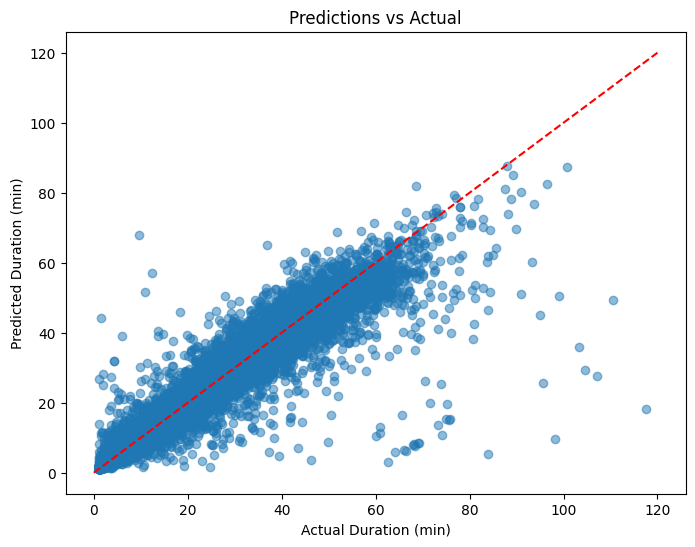

❌ LIMITED ANALYSIS: No error distribution, no feature importance, no residual plots


In [13]:
# ⚠️ PROBLEM 12: No error analysis, no visualizations
# Don't know where model fails

# Just one plot
y_pred = best_model.predict(X_test_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, 120], [0, 120], 'r--')
plt.xlabel('Actual Duration (min)')
plt.ylabel('Predicted Duration (min)')
plt.title('Predictions vs Actual')
plt.show()

print("❌ LIMITED ANALYSIS: No error distribution, no feature importance, no residual plots")

In [14]:
# ⚠️ PROBLEM 13: No documentation, no model card
# No one knows how to use this model

# Create a simple prediction function - no error handling
def predict_trip_duration(pickup_time, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon, 
                         passengers, distance, vendor, rate, payment, fare, tip, total):
    """
    ⚠️ This requires POST-TRIP information (fare, tip, total)!
    Can't actually use this at pickup time!
    """
    # Calculate features
    haversine_dist = haversine(pickup_lat, pickup_lon, dropoff_lat, dropoff_lon)
    hour = pd.to_datetime(pickup_time).hour
    dayofweek = pd.to_datetime(pickup_time).dayofweek
    month = pd.to_datetime(pickup_time).month
    
    # Create feature array
    features = np.array([[
        pickup_lon, pickup_lat, dropoff_lon, dropoff_lat,
        passengers, distance, fare, tip, total, vendor, rate, payment,
        haversine_dist, hour, dayofweek, month, distance/passengers, fare/distance
    ]])
    
    features_scaled = scaler.transform(features)
    prediction = best_model.predict(features_scaled)[0]
    
    return prediction

print("❌ DEPLOYMENT ISSUES:")
print("1. Model requires post-trip features (fare, tip, total)")
print("2. No validation that required features exist")
print("3. No error handling")
print("4. No documentation on expected inputs")

❌ DEPLOYMENT ISSUES:
1. Model requires post-trip features (fare, tip, total)
2. No validation that required features exist
3. No error handling
4. No documentation on expected inputs


In [15]:
# ⚠️ PROBLEM 14: No requirements.txt, no environment specification
# Can't reproduce the environment

# Try the model with example - will it work?
try:
    example_pred = predict_trip_duration(
        '2016-01-15 17:30:00',
        40.7580, -73.9855,  # pickup
        40.7829, -73.9772,  # dropoff
        2,                  # passengers
        2.5,               # distance
        2,                 # vendor
        1,                 # rate
        1,                 # payment
        12.5,             # fare (POST-TRIP!)
        3.0,              # tip (POST-TRIP!)
        16.0              # total (POST-TRIP!)
    )
    print(f"🚖 Predicted trip duration: {example_pred:.1f} minutes")
    print("⚠️ But this uses fare/tip/total - not available at pickup!")
except Exception as e:
    print(f"❌ Prediction failed: {e}")

🚖 Predicted trip duration: 15.7 minutes
⚠️ But this uses fare/tip/total - not available at pickup!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [16]:
# 📋 SUMMARY OF PROBLEMS - What students should notice:

problems = """
🔴 MAJOR ISSUES IN THIS NAIVE IMPLEMENTATION:

1.  ❌ NO REPRODUCIBILITY: No random seeds, different results each run
2.  ❌ DATA LEAKAGE: Using fare_amount, tip_amount, total_amount (post-trip info)
3.  ❌ DATA LEAKAGE: Feature engineering before train/test split
4.  ❌ NO CONFIGURATION: Hardcoded magic numbers everywhere
5.  ❌ NO VALIDATION SET: Can't detect overfitting properly
6.  ❌ NO CROSS-VALIDATION: Unreliable performance estimates
7.  ❌ NO HYPERPARAMETER TUNING: Using default parameters
8.  ❌ NO EXPERIMENT TRACKING: Can't compare runs, no history
9.  ❌ NO MODEL VERSIONING: Overwrites previous models
10. ❌ NO PROPER TEST SET: Used test set for model selection
11. ❌ NO ERROR ANALYSIS: Don't know where model fails
12. ❌ NO DOCUMENTATION: No model card, no usage instructions
13. ❌ DEPLOYMENT ISSUES: Model requires unavailable features
14. ❌ NO ENVIRONMENT SPEC: No requirements.txt
15. ❌ MESSY CODE: No organization, no classes, no functions
"""

print(problems)

print("\n💡 NEXT STEPS: Add best practices one by one")
print("1. Add configuration and reproducibility")
print("2. Fix data leakage (use only pickup-time features)")
print("3. Add proper train/validation/test splits")
print("4. Add cross-validation and hyperparameter tuning")
print("5. Add MLflow for experiment tracking")
print("6. Add model versioning and model registry")
print("7. Add comprehensive evaluation")
print("8. Add deployment-ready prediction service")


🔴 MAJOR ISSUES IN THIS NAIVE IMPLEMENTATION:

1.  ❌ NO REPRODUCIBILITY: No random seeds, different results each run
2.  ❌ DATA LEAKAGE: Using fare_amount, tip_amount, total_amount (post-trip info)
3.  ❌ DATA LEAKAGE: Feature engineering before train/test split
4.  ❌ NO CONFIGURATION: Hardcoded magic numbers everywhere
5.  ❌ NO VALIDATION SET: Can't detect overfitting properly
6.  ❌ NO CROSS-VALIDATION: Unreliable performance estimates
7.  ❌ NO HYPERPARAMETER TUNING: Using default parameters
8.  ❌ NO EXPERIMENT TRACKING: Can't compare runs, no history
9.  ❌ NO MODEL VERSIONING: Overwrites previous models
10. ❌ NO PROPER TEST SET: Used test set for model selection
11. ❌ NO ERROR ANALYSIS: Don't know where model fails
12. ❌ NO DOCUMENTATION: No model card, no usage instructions
13. ❌ DEPLOYMENT ISSUES: Model requires unavailable features
14. ❌ NO ENVIRONMENT SPEC: No requirements.txt
15. ❌ MESSY CODE: No organization, no classes, no functions


💡 NEXT STEPS: Add best practices one by one